<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/train_1s_30hz_initial_2class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Field Evaluation 1s 100hz

In [1]:
%load_ext autoreload
%autoreload 2

In [14]:
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import sys
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

sys.path.append('../../')   # Add parent directory to Python path
working_directory = "../models/"
sys.path.append('../../')
from utils.preprocessing import *

## 1.Load data

In [ ]:
with open('../../data/Field_validation/segmented_data_100hz.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

segments = loaded_data['segments']
segment_info = loaded_data['segment_info']

print(f"Loaded segments shape: {segments.shape}")
print(f"Loaded segment_info length: {len(segment_info)}")

Loaded segments shape: (2471, 100, 3)
Loaded segment_info length: 2471


In [10]:
df_segments_info = pd.DataFrame(segment_info)
df_segments_info.head(10)

,segment_id,start_time,end_time,start_index,curb_activity,curb_scene
0,0,2025-10-21 15:15:40.350,2025-10-21 15:15:41.340,0,0.0,0.0
1,1,2025-10-21 15:15:41.350,2025-10-21 15:15:42.340,100,0.0,0.0
2,2,2025-10-21 15:15:42.350,2025-10-21 15:15:43.340,200,0.0,0.0
3,3,2025-10-21 15:15:43.350,2025-10-21 15:15:44.340,300,0.0,0.0
4,4,2025-10-21 15:15:44.350,2025-10-21 15:15:45.340,400,0.0,0.0
5,5,2025-10-21 15:15:45.350,2025-10-21 15:15:46.340,500,0.0,0.0
6,6,2025-10-21 15:15:46.350,2025-10-21 15:15:47.340,600,0.0,0.0
7,7,2025-10-21 15:15:47.350,2025-10-21 15:15:48.340,700,0.0,0.0
8,8,2025-10-21 15:15:48.350,2025-10-21 15:15:49.340,800,0.0,0.0
9,9,2025-10-21 15:15:49.350,2025-10-21 15:15:50.340,900,0.0,0.0


In [11]:
# Extract curb_scene labels from segment_info
labels = np.array([info['curb_scene'] for info in segment_info])

print(f"Labels shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}")

Labels shape: (2471,)
Unique labels: [0. 1.]


In [12]:
# Convert labels to one-hot encoding
labels_one_hot = to_categorical(labels, num_classes=2)

print(f"Original labels shape: {labels.shape}")
print(f"One-hot labels shape: {labels_one_hot.shape}")
print(f"First 5 original labels: {labels[:5]}")
print(f"First 5 one-hot labels:\n{labels_one_hot[:5]}")

Original labels shape: (2471,)
One-hot labels shape: (2471, 2)
First 5 original labels: [0. 0. 0. 0. 0.]
First 5 one-hot labels:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [13]:
# Normalize segments
data_normalized = normalize_3d_data(segments)

## 2.Load model and evaluate

### a) linear model

In [15]:
full_eval_best_model_real_world_file_name = "../../models/1s_100hz_unbalanced/20251125-142243_simclr_linear_eval.keras"
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_real_world_file_name)

# Fix: Set is_one_hot=False since labels_one_hot contains integer labels, not one-hot encoded
print(simclr_utitlities.evaluate_model_simple(
    full_eval_best_model.predict(data_normalized), 
    labels_one_hot, 
    return_dict=True
))

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 100, 3))
  warnings.warn(msg)


78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
{'Confusion Matrix': array([[2294,  119],
       [  41,   17]]), 'F1 Macro': 0.5707796663163655, 'F1 Micro': 0.9352488870902469, 'F1 Weighted': 0.94773399873731, 'Precision': 0.553720556745182, 'Recall': 0.6218936221901482, 'Kappa': np.float64(0.1471921794313178)}


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 100, 3))
  warnings.warn(msg)


### b)full evaluation model

In [16]:
full_eval_best_model_real_world_file_name = "../../models/1s_100hz_unbalanced/20251125-142243_simclr_full_eval.keras"
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_real_world_file_name)

# Fix: Set is_one_hot=False since labels_one_hot contains integer labels, not one-hot encoded
print(simclr_utitlities.evaluate_model_simple(
    full_eval_best_model.predict(data_normalized), 
    labels_one_hot, 
    return_dict=True
))

 8/78 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step   

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 100, 3))
  warnings.warn(msg)


78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
{'Confusion Matrix': array([[2047,  366],
       [  33,   25]]), 'F1 Macro': 0.5112768835659727, 'F1 Micro': 0.8385269121813032, 'F1 Weighted': 0.8924212047277448, 'Precision': 0.5240366171552233, 'Recall': 0.6396780370693227, 'Kappa': np.float64(0.07348210686170675)}


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 100, 3))
  warnings.warn(msg)


 9/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 100, 3))
  warnings.warn(msg)


78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 100, 3))
  warnings.warn(msg)


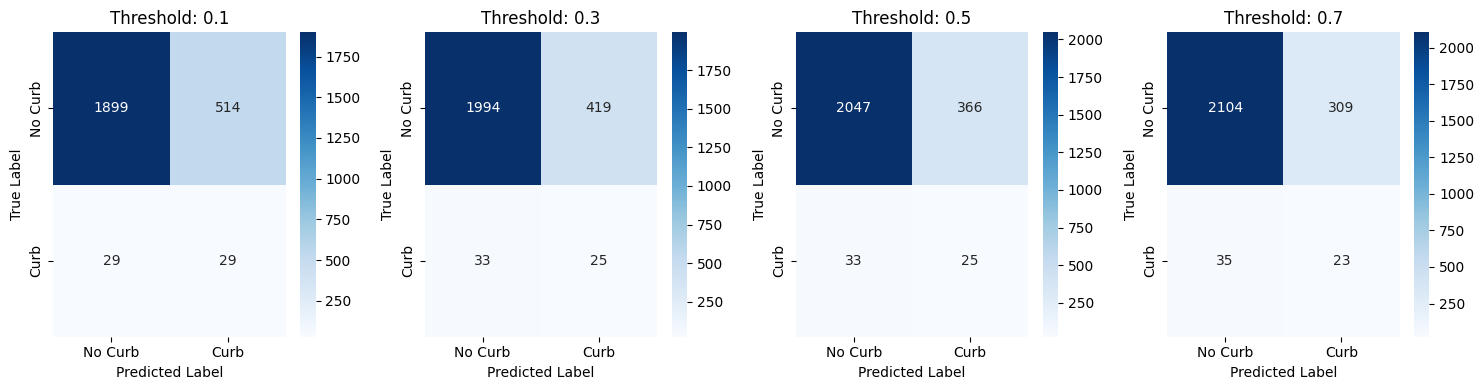


Summary Comparison
Threshold 0.1: Accuracy=0.7803, Precision=0.0534, Recall=0.5000
Threshold 0.3: Accuracy=0.8171, Precision=0.0563, Recall=0.4310
Threshold 0.5: Accuracy=0.8385, Precision=0.0639, Recall=0.4310
Threshold 0.7: Accuracy=0.8608, Precision=0.0693, Recall=0.3966


In [22]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys

sys.path.append('../../')
from utils.preprocessing import normalize_3d_data

# Load test data
with open('../../data/Field_validation/segmented_data_100hz.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

segments = loaded_data['segments']
segment_info = loaded_data['segment_info']
labels = np.array([info['curb_scene'] for info in segment_info])
data_normalized = normalize_3d_data(segments)

# Load model
full_eval_best_model_real_world_file_name = "../../models/1s_100hz_unbalanced/20251125-142243_simclr_full_eval.keras"
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_real_world_file_name)

# Get predictions
predictions = full_eval_best_model.predict(data_normalized)

# Test different thresholds
thresholds = [0.1,0.3, 0.5, 0.7]
results = {}

fig, axes = plt.subplots(1, len(thresholds), figsize=(15, 4))

for idx, threshold in enumerate(thresholds):
    # Convert predictions to binary labels using threshold
    binary_predictions = (predictions[:, 1] >= threshold).astype(int)
    
    # Generate confusion matrix
    cm = confusion_matrix(labels, binary_predictions)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    results[threshold] = {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp
    }
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['No Curb', 'Curb'],
                yticklabels=['No Curb', 'Curb'])
    axes[idx].set_title(f'Threshold: {threshold}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    
    # print(f"\n{'='*50}")
    # print(f"Threshold: {threshold}")
    # print(f"{'='*50}")
    # print(f"Confusion Matrix:\n{cm}")
    # print(f"  TN: {tn}, FP: {fp}")
    # print(f"  FN: {fn}, TP: {tp}")
    # print(f"  Accuracy:  {accuracy:.4f}")
    # print(f"  Precision: {precision:.4f}")
    # print(f"  Recall:    {recall:.4f}")
    # print(f"  F1-Score:  {f1:.4f}")

plt.tight_layout()
plt.show()

# Print summary comparison
print(f"\n{'='*50}")
print("Summary Comparison")
print(f"{'='*50}")
for threshold in thresholds:
    print(f"Threshold {threshold}: Accuracy={results[threshold]['accuracy']:.4f}, Precision={results[threshold]['precision']:.4f}, Recall={results[threshold]['recall']:.4f}")

## Extra: t-SNE Plots

In [ ]:
import sklearn.manifold
import seaborn as sns

In [28]:
# First load the model from the file path
# Load model
full_eval_best_model_real_world_file_name = "../../models/1s_100hz_unbalanced/20251125-142243_simclr_full_eval.keras"
loaded_model = tf.keras.models.load_model(full_eval_best_model_real_world_file_name)
perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(loaded_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(data_normalized, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "TPN_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 100, 32)        │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 100, 64)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 100, 96)        │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 96)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 49,248 (192.38 KB)

 Non-trainable params: 35,168 (137.38 KB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(600, 100, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 100, 3))
  warnings.warn(msg)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2471 samples in 0.000s...
[t-SNE] Computed neighbors for 2471 samples in 0.164s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2471
[t-SNE] Computed conditional probabilities for sample 2000 / 2471
[t-SNE] Computed conditional probabilities for sample 2471 / 2471
[t-SNE] Mean sigma: 1.187956
[t-SNE] KL divergence after 250 iterations with early exaggeration: 70.591728
[t-SNE] KL divergence after 1000 iterations: 1.216127


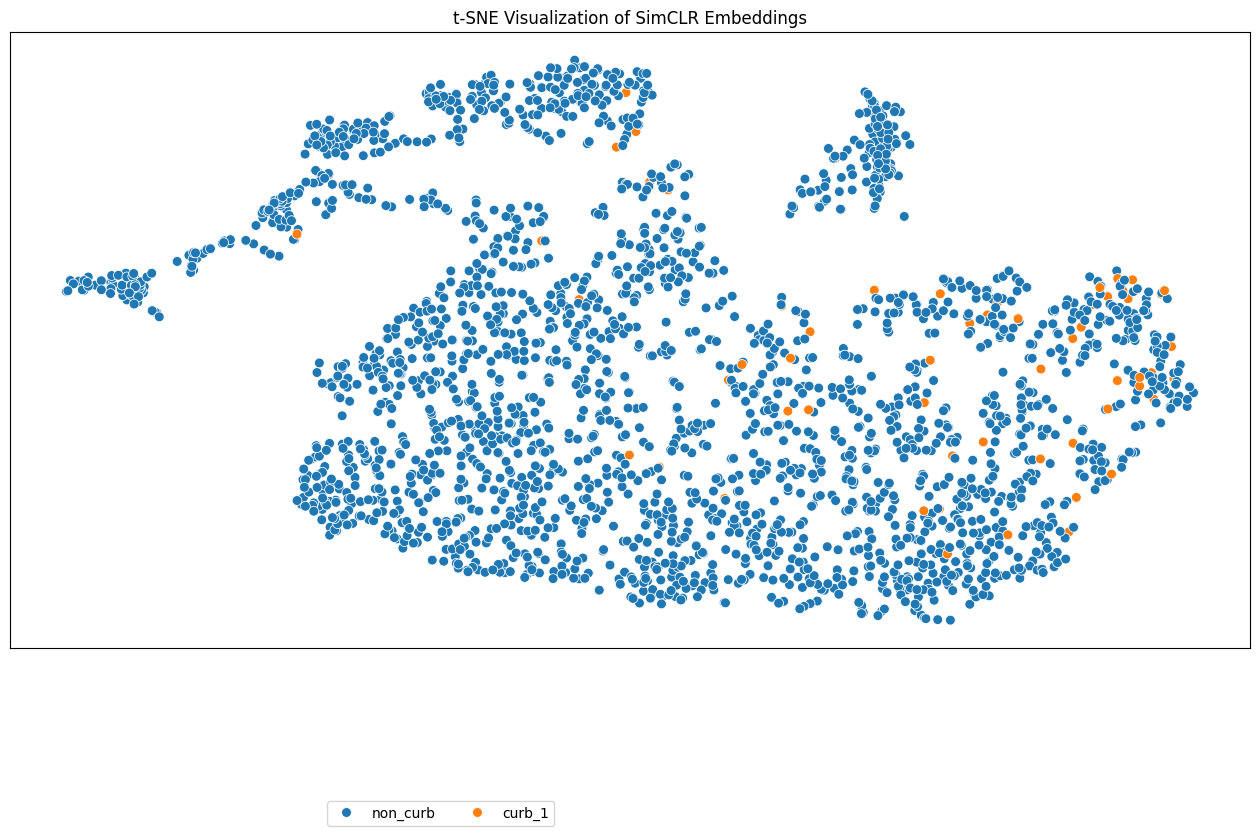

In [30]:
# Define colors
other_class_color = "#1f77b4"  # Blue
curb_1_color = "#ff7f0e"      # Yellow

# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(labels_one_hot, axis=1)
unique_labels = np.unique(labels_argmax)

# Create custom color palette
custom_palette = [other_class_color, curb_1_color]  # First color for non_curb (0), second for curb_1 (1)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=custom_palette,  # Use custom palette instead of "hsv"
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# Define your activity names
label_list_full_name = ["non_curb", "curb_1"]

# Update legend with custom colors
try:
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
    legend = graph.legend_
    if 'label_list_full_name' in globals():
        for j, label in enumerate(unique_labels):
            if label < len(label_list_full_name):
                legend.get_texts()[j].set_text(label_list_full_name[label])
except Exception as e:
    print(f"Warning: Could not customize legend - {e}")
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)